In [ ]:
# HMDA Mortgage Approval Analysis
## Overview: This project analyzes the 2022 Home Mortgage Disclosure Act (HMDA) dataset to explore factors associated with mortgage approval decisions. Using Python and Scikit-learn, the project demonstrates data preprocessing, exploratory data analysis, feature engineering, predictive modeling, and model evaluation.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler #makes everything into 1 and 0. Min Max scaler makes everything on the same scale
from sklearn.neighbors import KNeighborsClassifier #Want to classify, Regressor gives us numbers
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier #Ensemble Modeling, a collection of Trees that brings everything together.
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix #Let's us know how good our model is
import matplotlib.pyplot as plt


In [ ]:
df_project_data = pd.read_csv('/content/data/HMDA_2022.csv')
df_project_data.head()

,activity_year,state_code,county_code,census_tract,derived_ethnicity,derived_race,derived_sex,action_taken,loan_type,loan_purpose,loan_amount,loan_to_value_ratio,interest_rate,loan_term,property_value,occupancy_type,income,debt_to_income_ratio,applicant_age
0,2022,VA,51187,5.118702e+10,Not Hispanic or Latino,White,Joint,0.0,1.0,1.0,10000000.0,0.000,3.500,12.0,0.0,3.0,15376.0,<20%,45-54
1,2022,VA,51760,5.176006e+10,Ethnicity Not Available,Race Not Available,Sex Not Available,0.0,1.0,1.0,10000000.0,59.900,2.695,24.0,16905000.0,3.0,0.0,0,8888
2,2022,VA,51107,5.110761e+10,Not Hispanic or Latino,White,Male,0.0,3.0,1.0,1005000.0,100.000,3.375,360.0,1005000.0,1.0,155.0,50%-60%,35-44
3,2022,VA,51107,5.110761e+10,Not Hispanic or Latino,White,Male,0.0,1.0,1.0,1005000.0,80.000,5.625,360.0,1255000.0,1.0,247.0,37,35-44
4,2022,VA,51510,5.151020e+10,Ethnicity Not Available,Race Not Available,Joint,0.0,1.0,1.0,1005000.0,28.329,4.150,360.0,3535000.0,1.0,385.0,>60%,55-64


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["activity_year", "loan_purpose", "debt_to_income_ratio", "county_code", "census_tract",
                                                         "occupancy_type", "loan_type", "state_code", "derived_ethnicity", "derived_race",
                                                         "derived_sex", "applicant_age"]), # One-hot encode
        ("num", MinMaxScaler(), [
            "loan_amount",
            "income",
            "loan_to_value_ratio",
            "interest_rate",
            "loan_term",
            "property_value",
        ])
    ],
    remainder="passthrough"
)

In [ ]:
df_project_data.fillna(0, inplace=True)

In [ ]:
X = df_project_data.drop('action_taken', axis=1)
y = df_project_data['action_taken']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (18361, 18)
X_test shape: (7870, 18)
y_train shape: (18361,)
y_test shape: (7870,)


In [ ]:
categorical_cols_to_convert = ["activity_year", "loan_purpose", "debt_to_income_ratio", "county_code", "census_tract",
                               "occupancy_type", "loan_type", "state_code", "derived_ethnicity", "derived_race",
                               "derived_sex", "applicant_age"]

for col in categorical_cols_to_convert:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape of processed X_train: {X_train_processed.shape}")
print(f"Shape of processed X_test: {X_test_processed.shape}")

Shape of processed X_train: (18361, 2178)
Shape of processed X_test: (7870, 2178)


Random Forest Model

In [ ]:
from sklearn.metrics import recall_score
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42) # You can adjust n_estimators and other parameters
random_forest_model.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test_processed)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print("Random Forest Confusion Matrix:\n", conf_matrix_rf)

Random Forest Accuracy: 0.9938
Random Forest Precision: 0.9890
Random Forest Recall: 0.9668
Random Forest Confusion Matrix:
 [[6742   12]
 [  37 1079]]


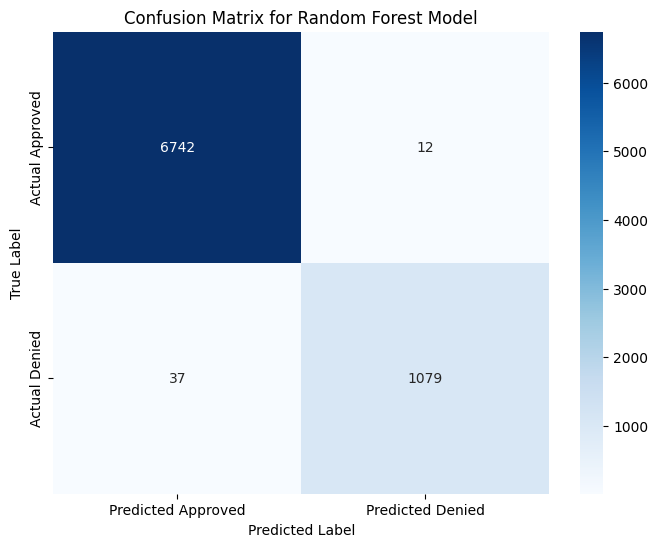

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred_rf are already defined from the previous Random Forest execution
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Approved', 'Predicted Denied'],
            yticklabels=['Actual Approved', 'Actual Denied'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest Model')
plt.show()

Decision Tree Model

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Decision Tree Model
# Using X_train_processed and X_test_processed for consistency with KNN
dt = DecisionTreeClassifier(max_depth=6, min_samples_split=20, random_state=42)
dt.fit(X_train_processed, y_train)
dt_preds = dt.predict(X_test_processed)

print("\n===== DECISION TREE =====")
print("Accuracy:", accuracy_score(y_test, dt_preds))
print("Precision:", precision_score(y_test, dt_preds, pos_label=1, zero_division=0))
print("Recall:", recall_score(y_test, dt_preds, pos_label=1, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_preds))


===== DECISION TREE =====
Accuracy: 0.9949174078780177
Precision: 0.9899817850637522
Recall: 0.9740143369175627
Confusion Matrix:
 [[6743   11]
 [  29 1087]]


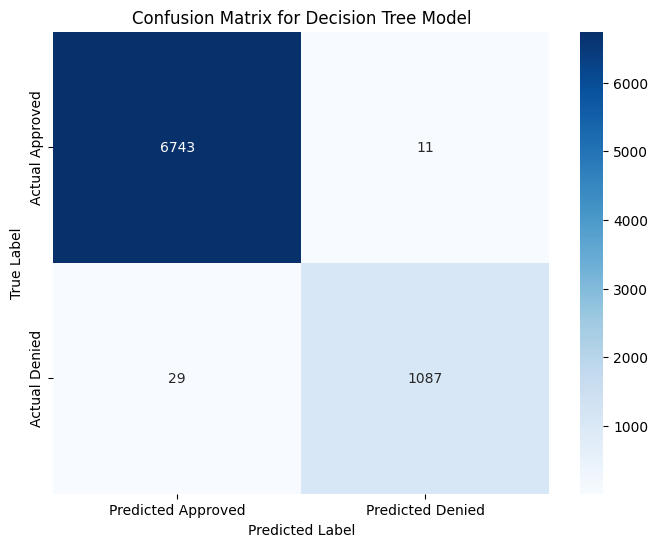

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_test and dt_preds are already defined from the previous Decision Tree execution
conf_matrix_dt = confusion_matrix(y_test, dt_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Approved', 'Predicted Denied'],
            yticklabels=['Actual Approved', 'Actual Denied'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree Model')
plt.show()

In [ ]:
df_new_data = pd.read_csv('/content/loan_tweets.csv')
df_new_data.head()

,tweet_id,created_at,username,text
0,tw_1077,9/28/2025 16:58,user_078,Online portal was easy to use and fast. #Custo...
1,tw_1005,9/28/2025 20:04,user_006,"Everything went as promised, no surprises. #De..."
2,tw_1047,9/29/2025 1:04,user_048,Got an email update — still under review. #Cus...
3,tw_1009,9/29/2025 13:48,user_010,"Everything went as promised, no surprises. #Ho..."
4,tw_1111,9/29/2025 14:47,user_112,@FirstCityBank made the loan approval fast and...


In [ ]:
df_new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   tweet_id    125 non-null    object
 1   created_at  125 non-null    object
 2   username    125 non-null    object
 3   text        125 non-null    object
dtypes: object(4)
memory usage: 4.0+ KB


Loan Tweets code


=== SENTIMENT DISTRIBUTION ===
sentiment
Positive    44
Neutral     44
Negative    12
Name: count, dtype: int64

=== THEME DISTRIBUTION ===
theme
Approval Experience    30
Other                  27
Rates/Fees             18
Fairness/Bias          17
Documentation           4
Customer Service        4
Name: count, dtype: int64

=== SENTIMENT BY THEME ===
sentiment            Negative  Neutral  Positive
theme                                           
Approval Experience        10        5        15
Customer Service            0        3         1
Documentation               0        3         1
Fairness/Bias               2        6         9
Other                       0       14        13
Rates/Fees                  0       13         5


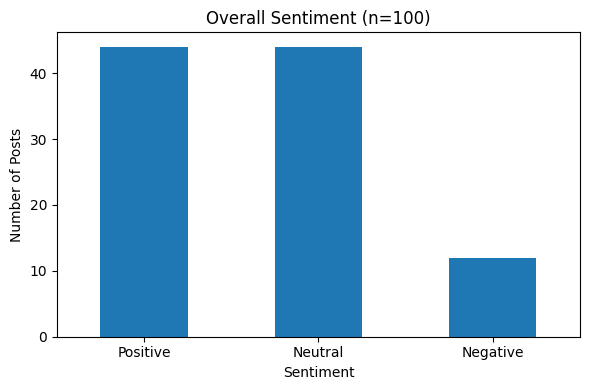

<Figure size 800x500 with 0 Axes>

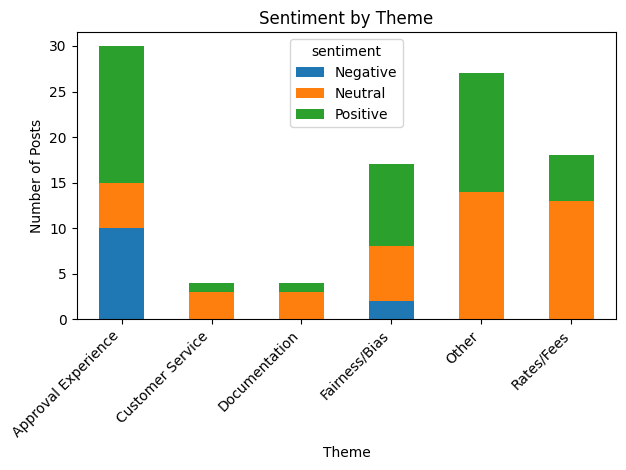

In [ ]:
df = pd.read_csv("/content/loan_tweets.csv")

possible_cols = ["text", "tweet", "post", "content", "message"]
text_col = None

for c in df.columns:
    if c.lower() in possible_cols:
        text_col = c
        break

if text_col is None:
    text_col = df.columns[0]

df = df[[text_col]].rename(columns={text_col: "text"}).dropna()
df = df.head(100)

positive_words = [
    "approved","fast","easy","helpful","good","great",
    "smooth","happy","satisfied","quick","love"
]

negative_words = [
    "denied","rejected","slow","bad","terrible","frustrating",
    "hate","unfair","confusing","angry","delay","delayed",
    "waiting","wait","problems","issue","issues"
]

def simple_sentiment(text):
    t = str(text).lower()
    pos = sum(w in t for w in positive_words)
    neg = sum(w in t for w in negative_words)
    if pos > neg:
        return "Positive"
    elif neg > pos:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["text"].apply(simple_sentiment)

#Classification

def contains_any(text, words):
    t = str(text).lower()
    return any(w in t for w in words)

def get_theme(text):
    t = str(text).lower()

    if contains_any(t, ["approved","denied","rejected","processing","waiting","status"]):
        return "Approval Experience"
    if contains_any(t, ["paperwork","documents","forms","upload","income verification","proof"]):
        return "Documentation"
    if contains_any(t, ["fair","unfair","bias","biased","discrimination","racist","treated"]):
        return "Fairness/Bias"
    if contains_any(t, ["interest","rate","apr","fees","charges","payment"]):
        return "Rates/Fees"
    if contains_any(t, ["customer service","phone","call","rep","agent","support"]):
        return "Customer Service"

    return "Other"

df["theme"] = df["text"].apply(get_theme)

#Summary Stats

sent_counts = df["sentiment"].value_counts()
theme_counts = df["theme"].value_counts()
sent_theme = pd.crosstab(df["theme"], df["sentiment"])

print("=== SENTIMENT DISTRIBUTION ===")
print(sent_counts)
print("\n=== THEME DISTRIBUTION ===")
print(theme_counts)
print("\n=== SENTIMENT BY THEME ===")
print(sent_theme)

#Visual 1
plt.figure(figsize=(6,4))
sent_counts.plot(kind="bar")
plt.title("Overall Sentiment (n=100)")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Visual 2
plt.figure(figsize=(8,5))
sent_theme.plot(kind="bar", stacked=True)
plt.title("Sentiment by Theme")
plt.xlabel("Theme")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
df_applicants = pd.read_csv('/content/Applicants to predict.csv')
df_applicants.head()

,activity_year,state_code,county_code,census_tract,loan_amount,property_value,loan_to_value_ratio,interest_rate,loan_term,income,debt_to_income_ratio,loan_type,loan_purpose,occupancy_type,derived_race,derived_ethnicity,derived_sex,applicant_age
0,2022,VA,51059,51107610800,314053,392632,84.19,6.560,180,184794,36%-<43%,1,1,1,Black or African American,Not Hispanic or Latino,Male,65-74
1,2023,VA,51510,51510202001,371704,113628,85.53,3.458,360,119194,30%-<36%,2,1,2,White,Not Hispanic or Latino,Sex Not Available,25-34
2,2023,MD,51059,51187020200,561741,361779,98.39,4.771,300,194794,43%-<50%,3,3,1,White,Not Hispanic or Latino,Female,45-54
3,2022,VA,51510,51059452600,555435,865108,49.76,4.632,300,199878,<20%,2,3,3,Black or African American,Not Hispanic or Latino,Sex Not Available,55-64
4,2022,MD,51059,51187020200,320174,167319,88.30,4.907,180,85307,43%-<50%,3,1,3,Race Not Available,Hispanic or Latino,Sex Not Available,35-44


In [ ]:
df_applicants.fillna(0, inplace=True)

In [ ]:
for col in categorical_cols_to_convert:
    if col in df_applicants.columns:
        df_applicants[col] = df_applicants[col].astype(str)

X_applicants_processed = preprocessor.transform(df_applicants)

print(f"Shape of processed applicant data: {X_applicants_processed.shape}")

Shape of processed applicant data: (25, 2178)


In [ ]:
# Decision Tree Model predictions
y_pred_applicants_dt = dt.predict(X_applicants_processed)
df_applicants['predicted_action_dt'] = y_pred_applicants_dt

print("\nDecision Tree Predictions:")
display(df_applicants[['activity_year', 'state_code', 'loan_amount', 'predicted_action_dt']].head())


Decision Tree Predictions:


,activity_year,state_code,loan_amount,predicted_action_dt
0,2022,VA,314053,0.0
1,2023,VA,371704,0.0
2,2023,MD,561741,0.0
3,2022,VA,555435,0.0
4,2022,MD,320174,0.0


In [ ]:
# Random Forest Model predictions
y_pred_applicants_rf = random_forest_model.predict(X_applicants_processed)
df_applicants['predicted_action_rf'] = y_pred_applicants_rf

print("\nRandom Forest Predictions:")
display(df_applicants[['activity_year', 'state_code', 'loan_amount', 'predicted_action_rf']].head())


Random Forest Predictions:


,activity_year,state_code,loan_amount,predicted_action_rf
0,2022,VA,314053,0.0
1,2023,VA,371704,0.0
2,2023,MD,561741,0.0
3,2022,VA,555435,0.0
4,2022,MD,320174,0.0


In [ ]:
# Display a comparison of predictions from all models (if available)
# Display a comparison of predictions from both models
print("\nCombined Predictions:")
display(df_applicants[['activity_year', 'state_code', 'loan_amount', 'predicted_action_rf', 'predicted_action_dt']].head())

# Initialize columns_to_display before using it
columns_to_display = ['activity_year', 'state_code', 'loan_amount']

if 'predicted_action_dt' in df_applicants.columns:
    columns_to_display.append('predicted_action_dt')
if 'predicted_action_rf' in df_applicants.columns:
    columns_to_display.append('predicted_action_rf')

display(df_applicants[columns_to_display].head())


Combined Predictions:


,activity_year,state_code,loan_amount,predicted_action_rf,predicted_action_dt
0,2022,VA,314053,0.0,0.0
1,2023,VA,371704,0.0,0.0
2,2023,MD,561741,0.0,0.0
3,2022,VA,555435,0.0,0.0
4,2022,MD,320174,0.0,0.0


,activity_year,state_code,loan_amount,predicted_action_dt,predicted_action_rf
0,2022,VA,314053,0.0,0.0
1,2023,VA,371704,0.0,0.0
2,2023,MD,561741,0.0,0.0
3,2022,VA,555435,0.0,0.0
4,2022,MD,320174,0.0,0.0


In [ ]:
display(df_applicants)

,activity_year,state_code,county_code,census_tract,loan_amount,property_value,loan_to_value_ratio,interest_rate,loan_term,income,debt_to_income_ratio,loan_type,loan_purpose,occupancy_type,derived_race,derived_ethnicity,derived_sex,applicant_age,predicted_action_dt,predicted_action_rf
0,2022,VA,51059,51107610800,314053,392632,84.19,6.560,180,184794,36%-<43%,1,1,1,Black or African American,Not Hispanic or Latino,Male,65-74,0.0,0.0
1,2023,VA,51510,51510202001,371704,113628,85.53,3.458,360,119194,30%-<36%,2,1,2,White,Not Hispanic or Latino,Sex Not Available,25-34,0.0,0.0
2,2023,MD,51059,51187020200,561741,361779,98.39,4.771,300,194794,43%-<50%,3,3,1,White,Not Hispanic or Latino,Female,45-54,0.0,0.0
3,2022,VA,51510,51059452600,555435,865108,49.76,4.632,300,199878,<20%,2,3,3,Black or African American,Not Hispanic or Latino,Sex Not Available,55-64,0.0,0.0
4,2022,MD,51059,51187020200,320174,167319,88.30,4.907,180,85307,43%-<50%,3,1,3,Race Not Available,Hispanic or Latino,Sex Not Available,35-44,0.0,0.0
5,2022,VA,51187,51510202001,355504,998490,93.87,4.896,240,66262,43%-<50%,4,1,1,White,Not Hispanic or Latino,Female,>=75,0.0,0.0
6,2022,NC,51510,51510202001,570785,627253,98.26,7.665,180,60029,>60%,3,3,2,White,Hispanic or Latino,Sex Not Available,35-44,0.0,0.0
7,2022,MD,51059,51510202001,267330,1164685,94.76,7.723,300,197496,43%-<50%,2,1,2,Black or African American,Ethnicity Not Available,Male,65-74,0.0,0.0
8,2023,VA,51107,51059452600,402451,602167,43.48,7.768,180,52453,>60%,4,1,3,Black or African American,Not Hispanic or Latino,Sex Not Available,65-74,0.0,0.0
9,2023,MD,51187,51013100200,302086,521844,82.78,4.894,300,144845,43%-<50%,4,1,1,Black or African American,Not Hispanic or Latino,Joint,25-34,0.0,0.0


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

df_encoded = df_project_data.copy()

# Ensure 'action_taken' is part of the dataframe for correlation analysis
# It's already numeric (0 or 1), so no special encoding needed.
print("Created df_encoded copy and imported OrdinalEncoder.")

Created df_encoded copy and imported OrdinalEncoder.


In [ ]:
numerical_cols_for_corr = [col for col in df_project_data.columns if col not in categorical_cols_to_convert and col != 'action_taken']

# Instantiate OrdinalEncoder
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Apply OrdinalEncoder to categorical columns in df_encoded
for col in categorical_cols_to_convert:
    # Reshape the column to a 2D array and fit_transform
    df_encoded[col] = ordinal_encoder.fit_transform(df_encoded[[col]])

# Include 'action_taken' for correlation analysis
df_encoded['action_taken'] = df_project_data['action_taken']

print("Categorical columns in df_encoded have been ordinally encoded.")
print("Numerical columns identified and 'action_taken' included.")


Categorical columns in df_encoded have been ordinally encoded.
Numerical columns identified and 'action_taken' included.


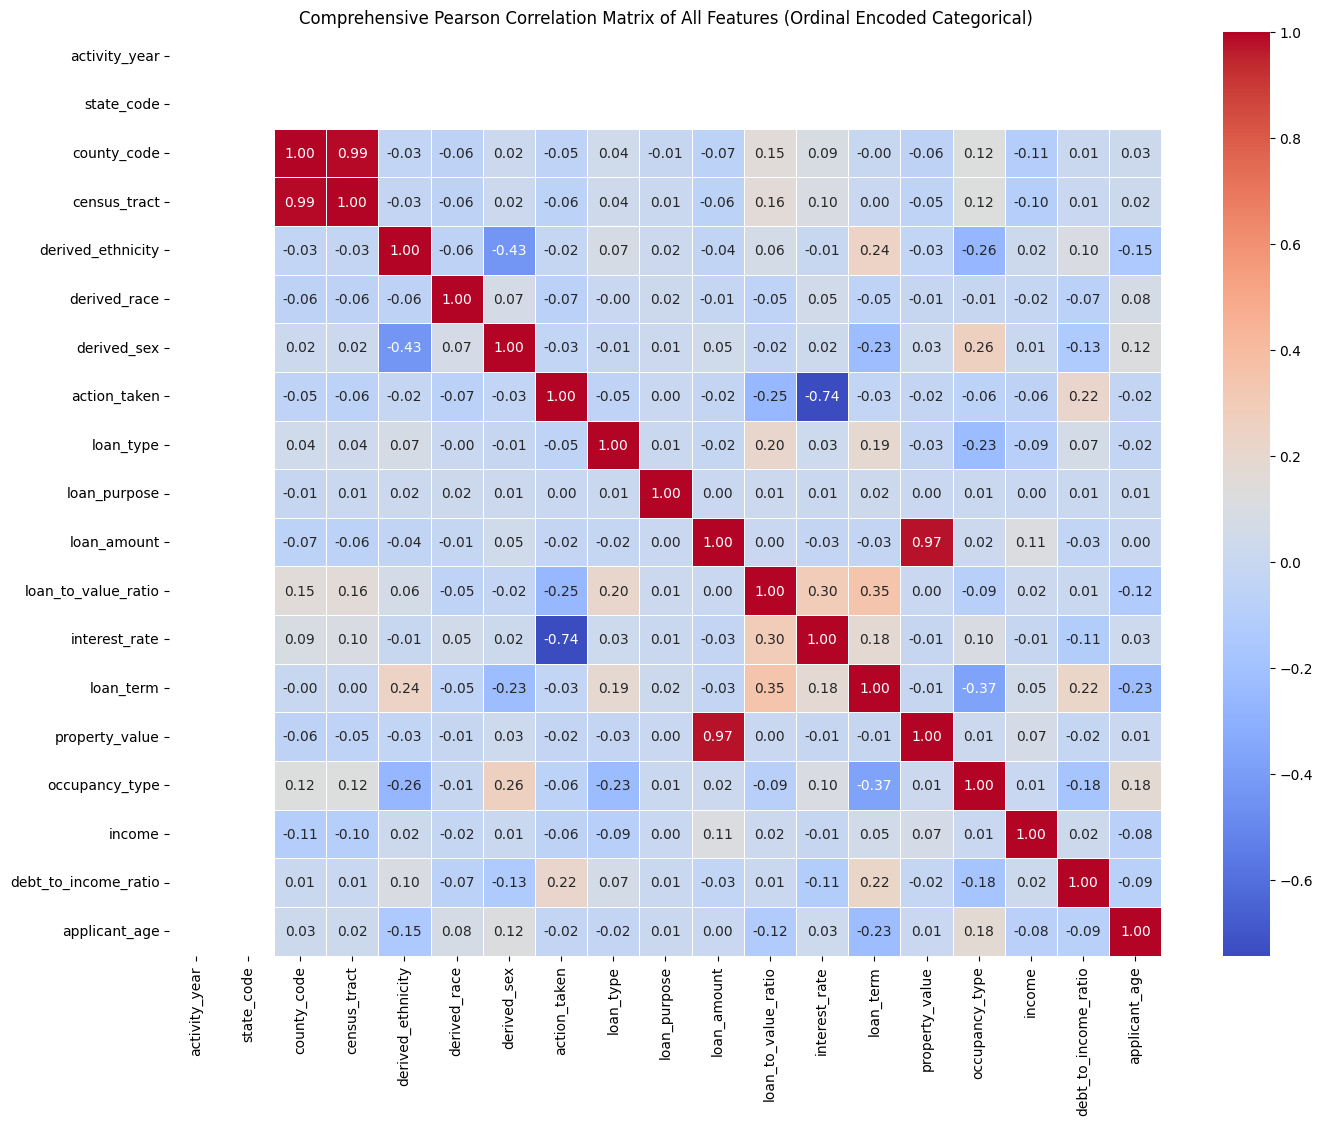

Correlation matrix calculated and visualized successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(16, 12)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Comprehensive Pearson Correlation Matrix of All Features (Ordinal Encoded Categorical)')
plt.show()

print("Correlation matrix calculated and visualized successfully.")

In [ ]:
## Conclusion: This project demonstrates an end-to-end machine learning workflow, including preprocessing, feature engineering, supervised learning, and evaluation using the HMDA dataset. The analysis highlights how data-driven techniques can be applied to financial datasets while emphasizing the importance of understanding dataset limitations and ethical considerations.